In [1]:
import ccdproc
from os import listdir
from astropy.io import fits
import glob
import pylab
from astropy.table import Table
import numpy as np 
import ccdproc as cp 
from glob import glob
import matplotlib.pyplot as plt
from ccdproc import *   
import astropy.units as u
import os
from glob import glob
import glob
import math 

In [2]:
# subtract_fits_images('HIP19139-g80o50-0001-100ms.fit', 'dark-g80o50-0004-100ms.fit', 'HIP19139-g80o50-0001-100ms-subdark.fit')

In [3]:
# def takemean( path ):
#     fh=fits.open(path)     
#     return  fh[0].data[1050:1106,930:964].mean()

def takestat( path ):
    fh=fits.open(path)
     
        
    #return fh[0].header["EXPTIME"], fh[0].data[644:1140,860:1110].sum()   ### 取总和   
    return fh[0].header["EXPTIME"], fh[0].data[680:1140,890:1090].sum()   ### 取总和   要尽量大 覆盖到


    #return fh[0].header["EXPTIME"], fh[0].data[975:1114,918:995].mean()   ###取小范围    
    #return fh[0].header["EXPTIME"], fh[0].data[828:1212,886:1068].mean()    ####取适当范围（基本包括全部）


# def takevariance( path ):
#     fh=fits.open(path)
#     return  fh[0].data[1050:1106,930:964].var()/2

def takestd( path ):
    fh=fits.open(path)
    return  fh[0].data[650:1130,910:1150].std()
    
 

In [4]:
#实验
rows = []
for afile in glob.glob("200nm-0005-0d04s-subdark.fit"):
    rows.append(takestat(afile))
    print(rows)

[(0.04, 480463771.20000005)]


exptime
-------
   0.01
   0.02
   0.03
   0.04
      count       
------------------
       122697535.2
249247359.99999997
       365957659.2
484614491.20000005


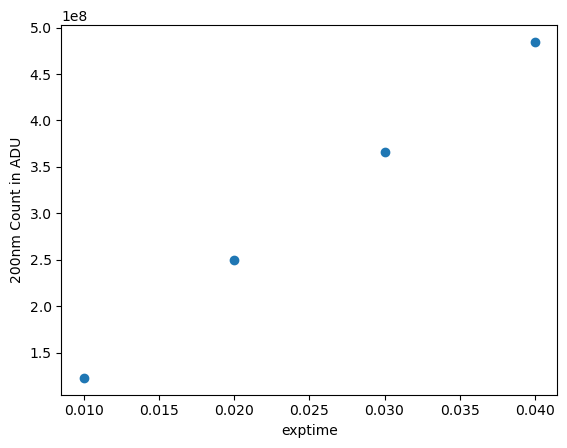

In [5]:

rows = []
for afile in glob.glob("200nm-0006*subdark.fit"):
    rows.append(takestat(afile))
table = Table(rows=rows,names=("exptime","count")) 
pylab.xlabel("exptime")
pylab.ylabel("200nm Count in ADU")
pylab.plot(table["exptime"],table["count"],"o")

print(table["exptime"])
print(table["count"])
#5.236e+09 x - 3.279e+06


RMSE= 2372782.7790182955
z1= [1.20246117e+10 5.01396960e+06]
拟合后的公式是：
p1= 
1.202e+10 x + 5.014e+06± 2372782.7790182955


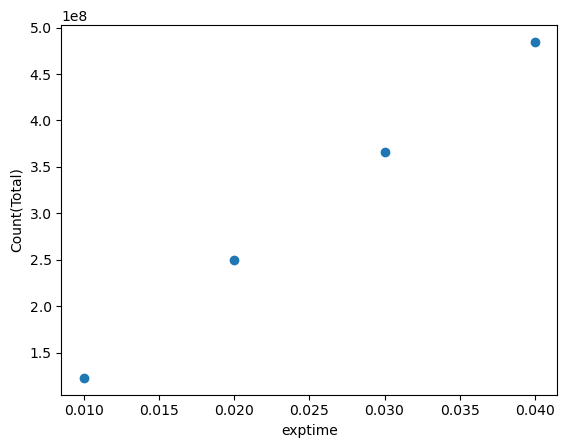

In [6]:
X = table["exptime"]
Y = table["count"]
pylab.xlabel("exptime")
pylab.ylabel("Count(Total)")
pylab.plot(X,Y,"o")

z1 = np.polyfit(X, Y, 1)   ###线性拟合
slope, intercept = z1
y_fit = slope * X + intercept
residuals = Y - y_fit#残差
mse = np.mean(residuals**2)#均方误差
rmse = np.sqrt(mse)#均方根误差
p1 = np.poly1d(z1)
print('RMSE=',rmse)

print('z1=',z1)
print("拟合后的公式是：") 
#print('p1=',p1)#± 

#print("a ==  %s ,b == %s" % (a, b))
print("p1=%s± %s" % (p1,rmse))


In [11]:
from uncertainties import ufloat
x = ufloat(1.202e+10  + 5.014e+06, 2372782.7790182955)
print("一秒钟内的count数是",x)
gain =ufloat(0.086,0.007)
electron_num = gain * x
print("一秒钟内的电子数是")
print(f"{electron_num}")  

photo_num= ufloat(8849178685,61448005.31)

QE=electron_num / photo_num
print(QE)

一秒钟内的count数是 (1.20250+/-0.00024)e+10
一秒钟内的电子数是
(1.03+/-0.08)e+09
0.117+/-0.010
